In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
import numpy as np
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")

## SPECT Image Reconstruction

The scatter-corrected projection data generated in the previous steps are now reconstructed using **SIRF/STIR**.

We will perform an **OSEM (Ordered Subsets Expectation Maximisation)** reconstruction incorporating:

- **attenuation correction** using the phantom attenuation map;
- **collimator-detector response / resolution modelling**;
- a **Poisson log-likelihood** objective function.

The reconstruction parameters and system model are defined explicitly, allowing the reconstruction pipeline to be inspected and modified.

In [2]:
# Select the dataset to reconstruct
sim_dir = demo_path / "simind_data" / "lu177_128"
# sim_dir = demo_path / "simind_data" / "tc99m_128"

# Scatter-corrected projection data
tomo_cor = sim_dir / "tomo" / "lu177_simulation_tew.hs"
# tomo_cor = sim_dir / "tomo" / "tc99m_simulation_dew.hs"

# Attenuation map
ctac = sim_dir / "input" / "nema_lu_ctac.hv"
# ctac = sim_dir / "input" / "nema_tc_ctac.hv"

## Load the Projection Data and Define Reconstruction Parameters

The **scatter-corrected projection data** and corresponding **attenuation map** are loaded into SIRF/STIR.

The reconstruction image geometry is defined independently of the projection data. Here we use a **128 × 128 × 128** matrix with **4.42 mm isotropic voxels**.

The OSEM reconstruction is configured with:

- **2 subsets**
- **100 subiterations**

Intermediate reconstructed images can also be saved during the iterative reconstruction.

In [ ]:
# Load scatter-corrected projection data
acquisition_data = spect.AcquisitionData(str(tomo_cor))

# Reconstruction image geometry
matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

# OSEM parameters
subiterations = 100
subsets = 2
save_interval = 10

# Reconstruction output
recon_dir = sim_dir / "recons" / "osem"
recon_dir.mkdir(parents=True, exist_ok=True)

name_prefix = "lu177_sim_osem"
# name_prefix = "tc99m_sim_osem"

# Load attenuation map
attenuation_map = spect.ImageData(str(ctac))

keep_views_in_cache = False

## Create the Initial Image

Iterative reconstruction requires an **initial estimate** of the activity distribution.

A SIRF/STIR `ImageData` object is created with the required reconstruction geometry and initialised uniformly to **1**.

This image provides the starting estimate that will subsequently be updated by the OSEM algorithm.

In [ ]:
# Create a template for the reconstructed image
initial_image = spect.ImageData(acquisition_data)
initial_image.initialise(matrix_size, vsize=voxel_size)
initial_image.set_modality("NM")

# Uniform initial estimate
initial_image.fill(1)

## Configure the SPECT System Model

The **acquisition model** describes how an activity distribution in image space produces SPECT projection data.

A `SPECTUBMatrix` is used to model the SPECT imaging system. The model includes two important physical effects:

- **Attenuation** — spatially varying photon attenuation is modelled using the attenuation map.
- **Collimator-detector response** — the distance-dependent loss of spatial resolution is represented using a parameterised resolution model.

The resolution model is defined by an intrinsic Gaussian width (`sigma_0`) and a distance-dependent component (`slope`).

The resulting system matrix is used by SIRF/STIR's ray-tracing acquisition model during iterative reconstruction.

In [ ]:
# Parameters for the distance-dependent resolution model
sigma_0 = 2.35598  # mm
slope = 0.01771

# Create the SPECT system matrix
acq_model_matrix = spect.SPECTUBMatrix()

# Optionally cache projection views to speed up reconstruction
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)


# -------------------------------------------------------------------------
# Attenuation correction
# -------------------------------------------------------------------------

# The attenuation map is currently flipped to account for the image
# orientation expected by this STIR configuration.
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

acq_model_matrix.set_attenuation_image(flipped_attenuation_map)


# -------------------------------------------------------------------------
# Resolution modelling
# -------------------------------------------------------------------------

acq_model_matrix.set_resolution_model(
    float(sigma_0),
    float(slope),
    full_3D=False
)


# -------------------------------------------------------------------------
# Acquisition model
# -------------------------------------------------------------------------

am = spect.AcquisitionModelUsingMatrix(acq_model_matrix)

# Configure the model for the measured projections and image geometry
am.set_up(acquisition_data, initial_image)

## Define the Objective Function

Image reconstruction is formulated as an optimisation problem.

For emission tomography, the measured projection data are modelled using **Poisson counting statistics**. SIRF/STIR therefore constructs a **Poisson log-likelihood objective function** from the acquired projection data.

The acquisition model defined above connects this statistical model to the physical SPECT imaging system.

In [ ]:
# Create the Poisson log-likelihood objective function
obj_fun = spect.make_Poisson_loglikelihood(acquisition_data)

# Associate it with the SPECT acquisition model
obj_fun.set_acquisition_model(am)

## Perform the OSEM Reconstruction

The image is reconstructed using **Ordered Subsets Expectation Maximisation (OSEM)**.

OSEM accelerates maximum-likelihood expectation maximisation by dividing the projection data into subsets and updating the image sequentially using each subset.

The reconstructor is configured with the selected number of **subsets** and **subiterations**, together with the Poisson objective function and SPECT acquisition model.

The reconstructed image therefore incorporates:

**scatter correction → attenuation correction → resolution modelling → iterative OSEM reconstruction**

In [ ]:
# Create the image that will be updated during reconstruction
reconstructed_image = initial_image.clone()

# Configure the OSEM reconstructor
recon = spect.OSMAPOSLReconstructor()

recon.set_num_subiterations(subiterations)
recon.set_num_subsets(subsets)

# Save intermediate reconstruction results
recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(recon_dir / name_prefix))

# Set the objective function
recon.set_objective_function(obj_fun)

# Initialise and run the reconstruction
recon.set_up(reconstructed_image)
recon.reconstruct(reconstructed_image)

## Compare OSEM Reconstructions With and Without Resolution Modelling

The reconstructed images are now inspected at different numbers of **OSEM subiterations**.

For each reconstruction step, the same transverse slice is displayed for:

- **OSEM** — reconstruction with attenuation and scatter correction.
- **OSEM-RM** — the same reconstruction with additional **collimator-detector response (resolution) modelling**.

Both images are displayed using the **same intensity scale**, allowing direct visual comparison of the effect of resolution modelling and reconstruction convergence.

Progressing through the subiterations also illustrates how the reconstructed image evolves as the iterative algorithm converges.

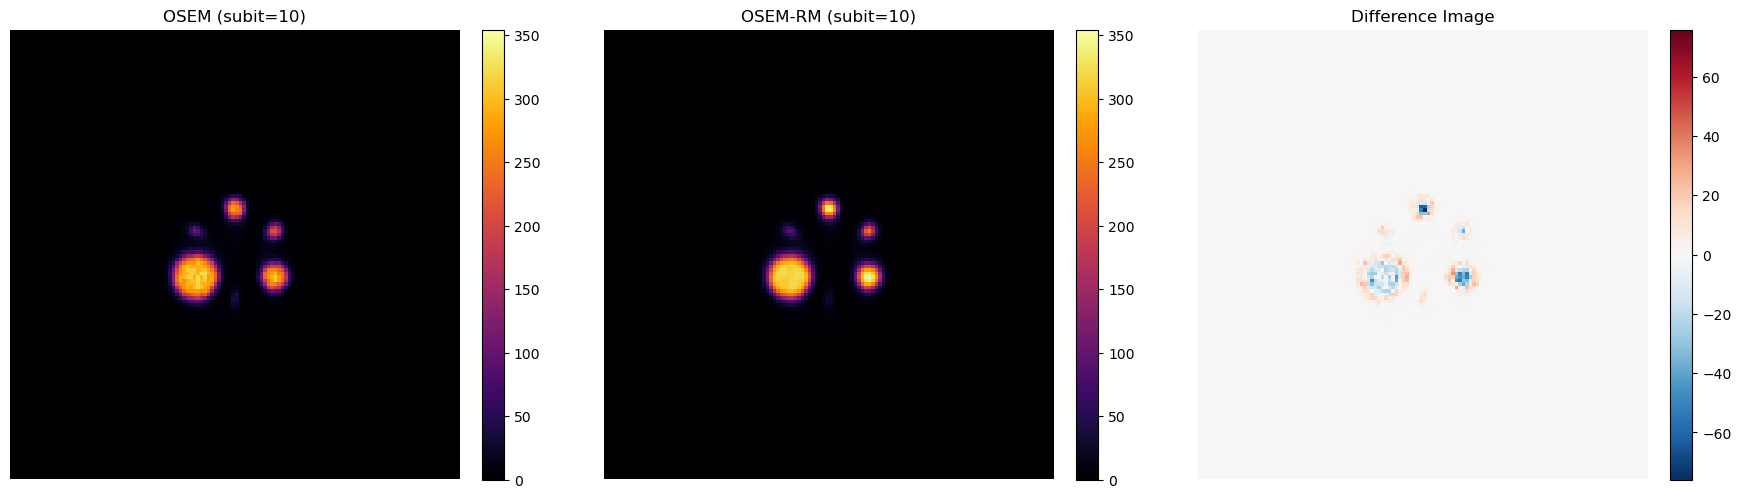

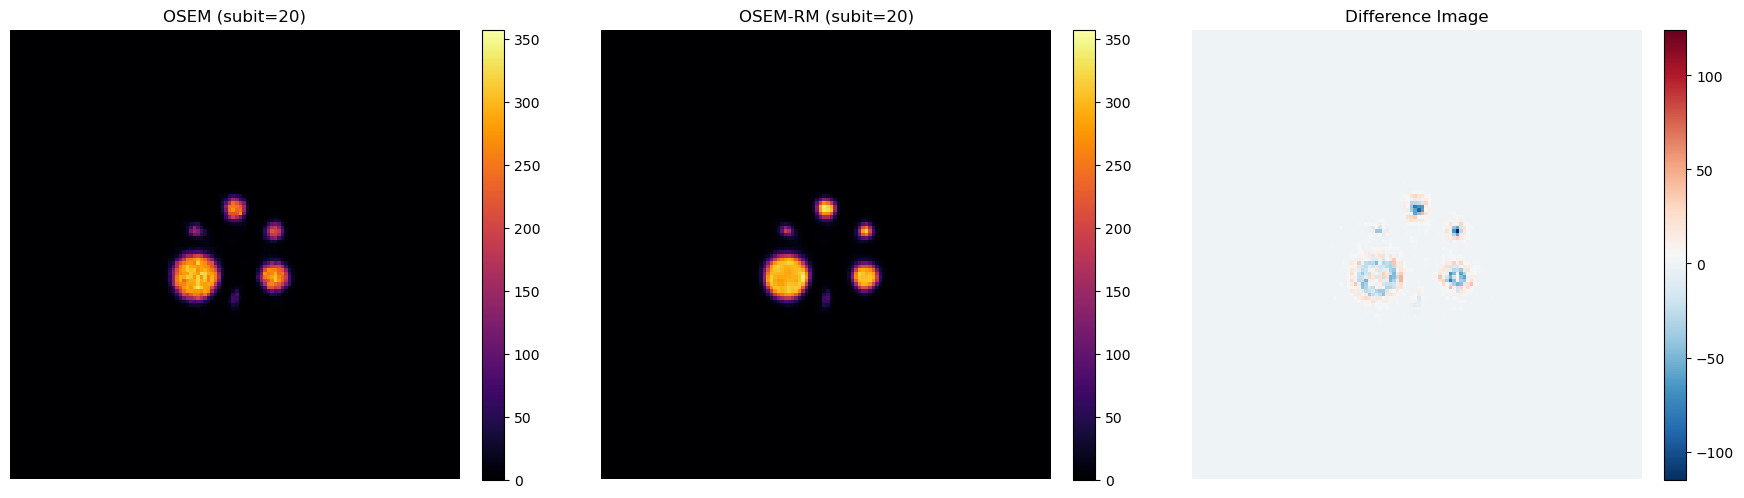

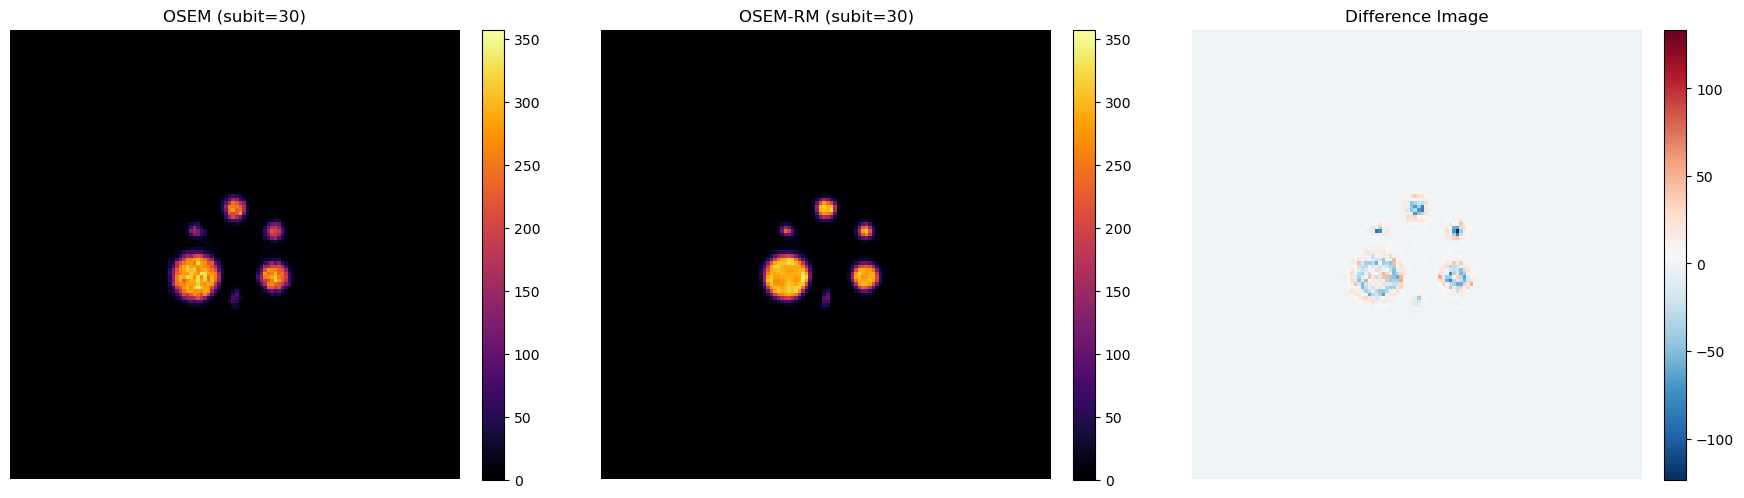

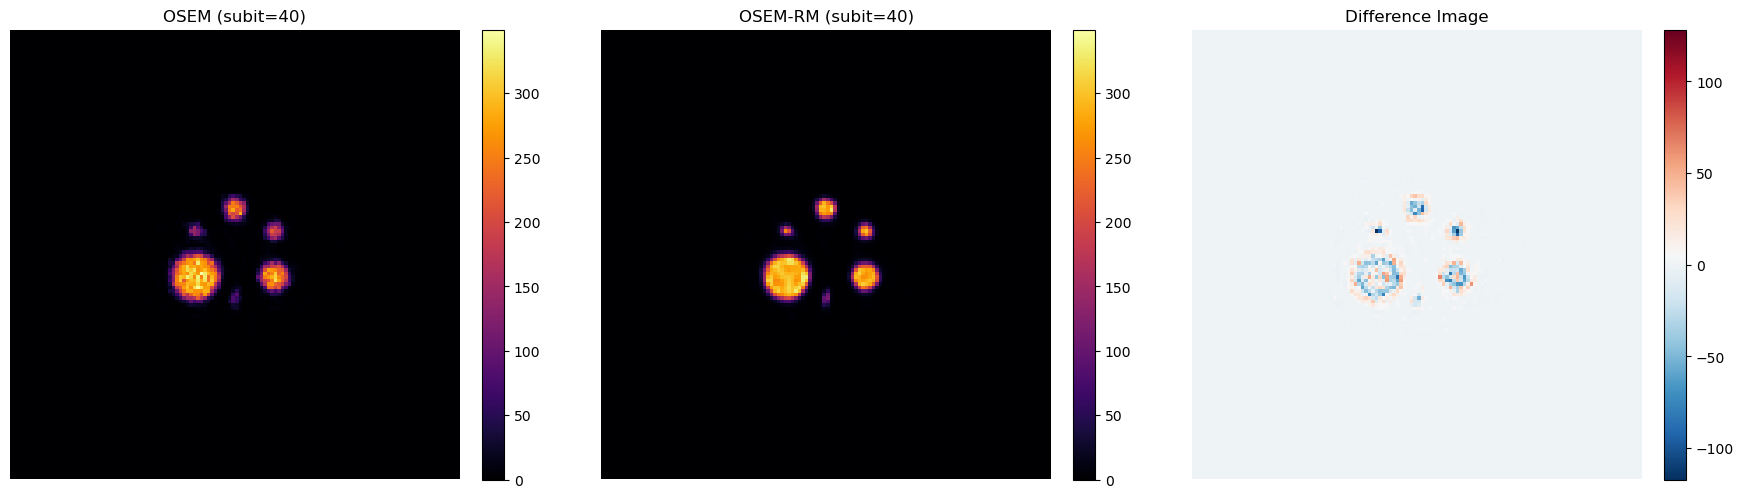

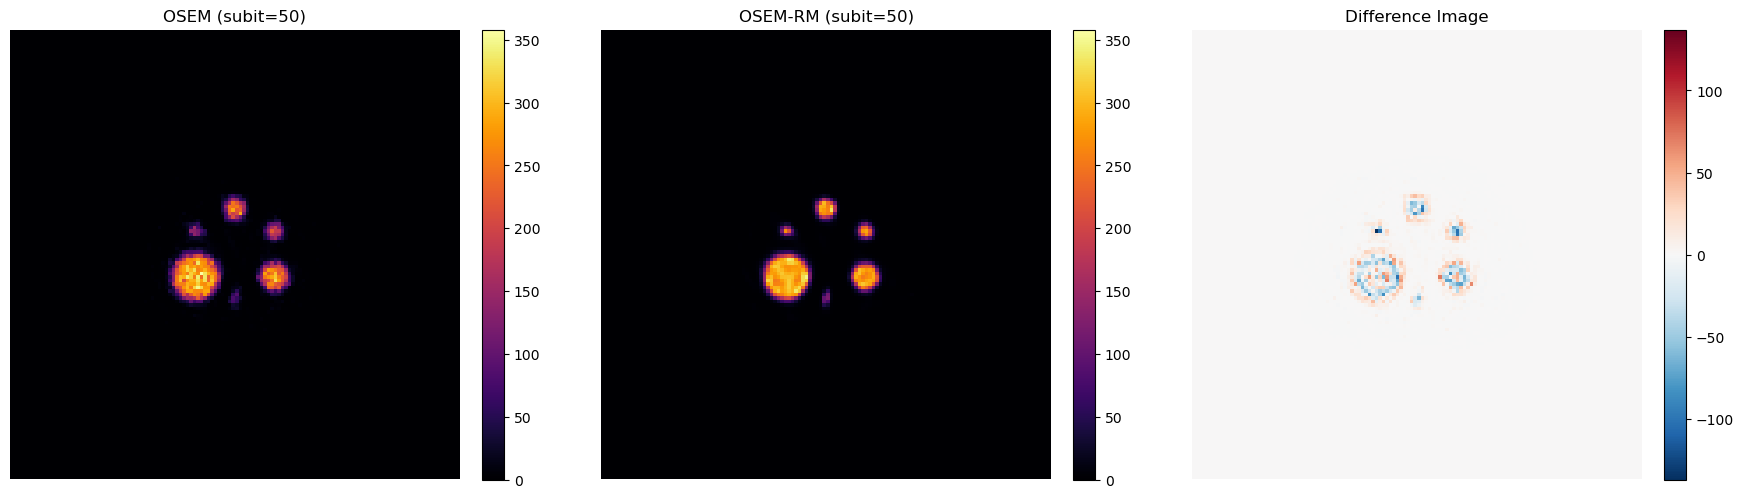

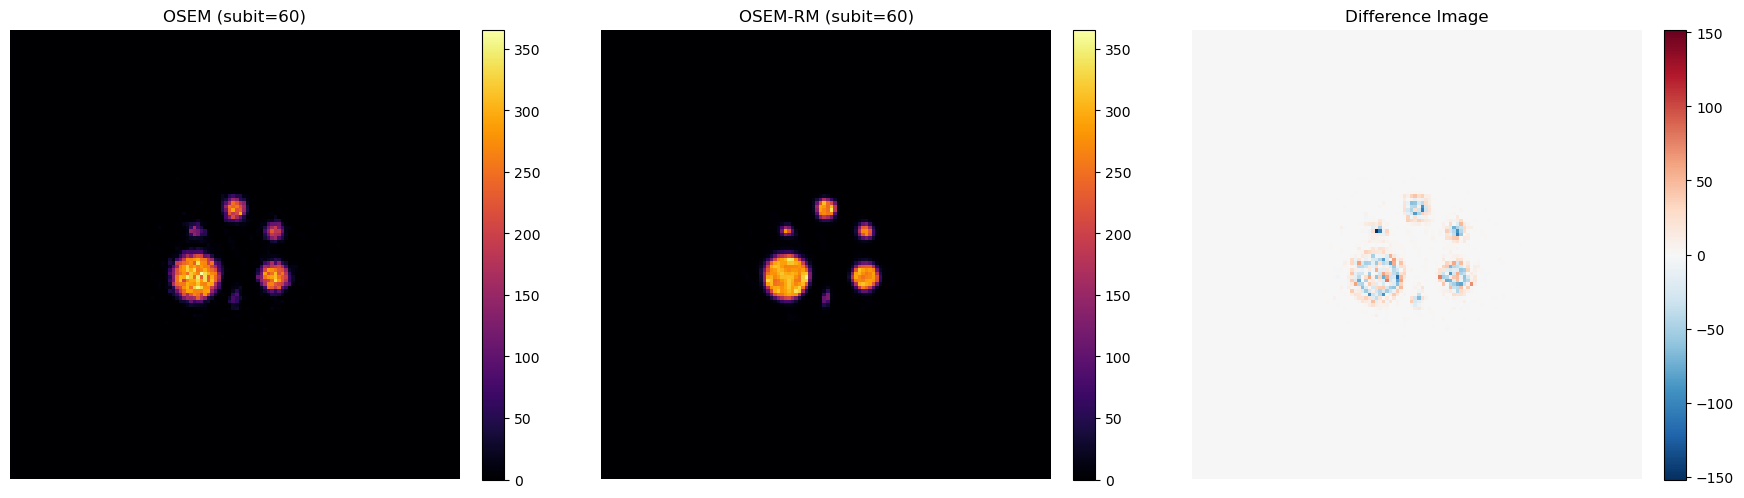

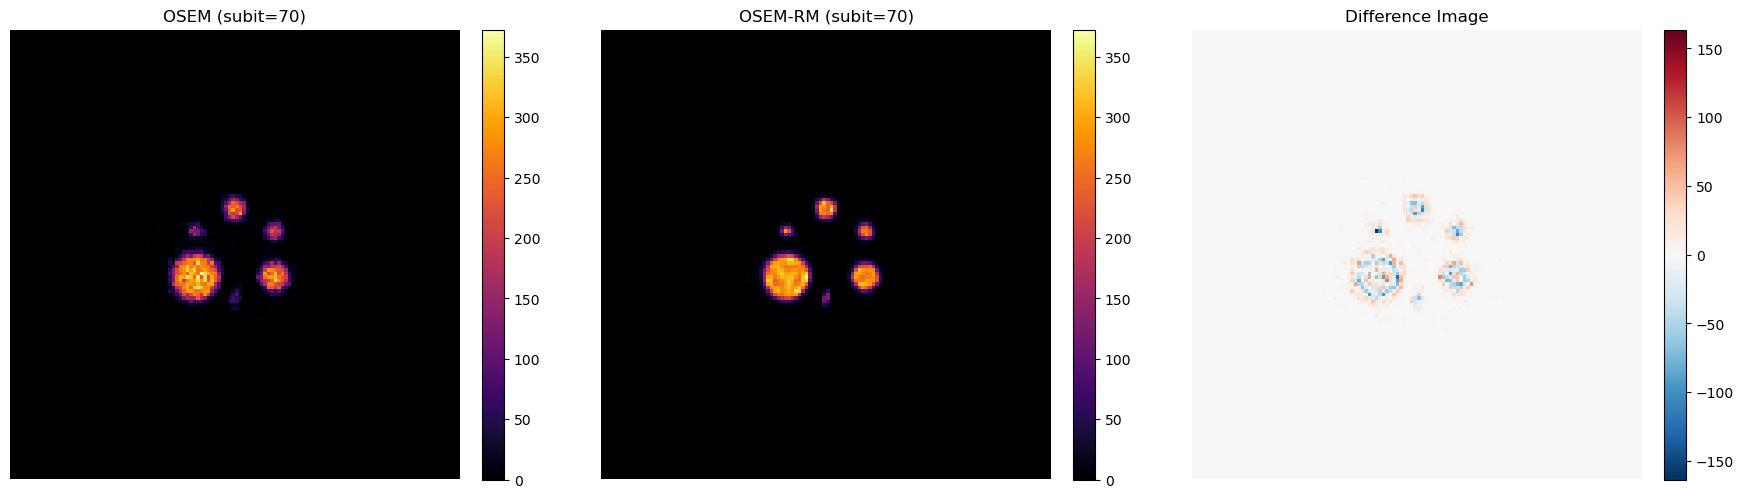

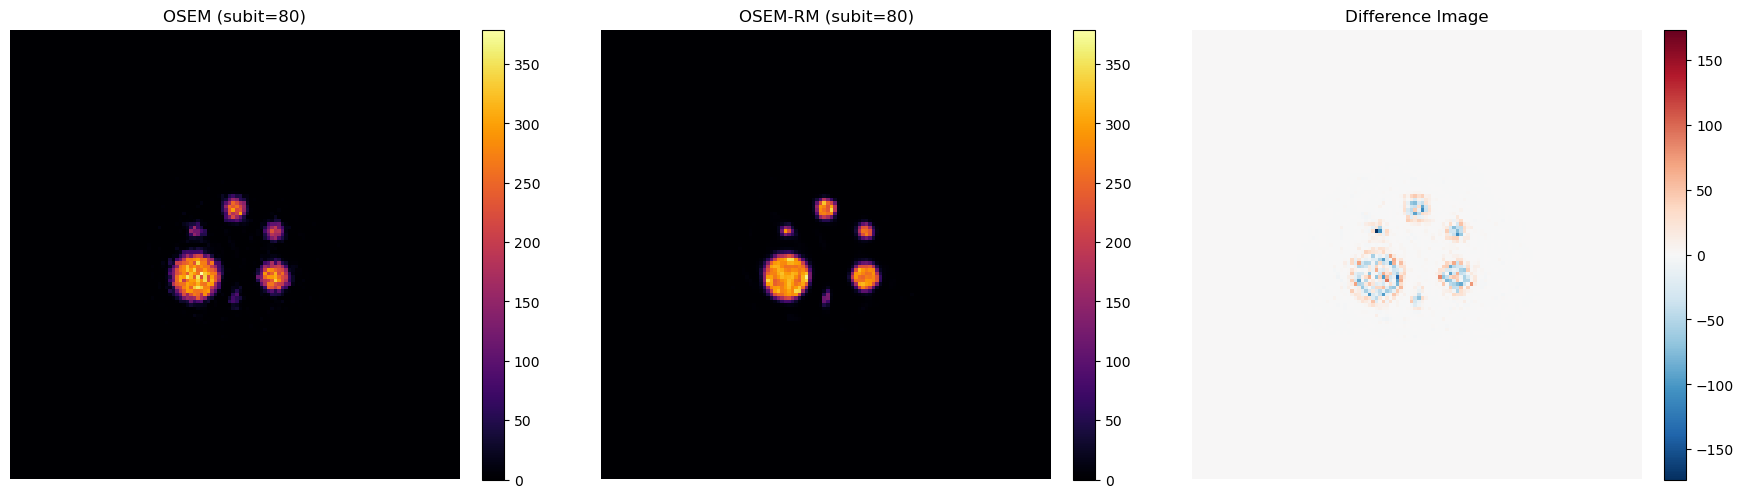

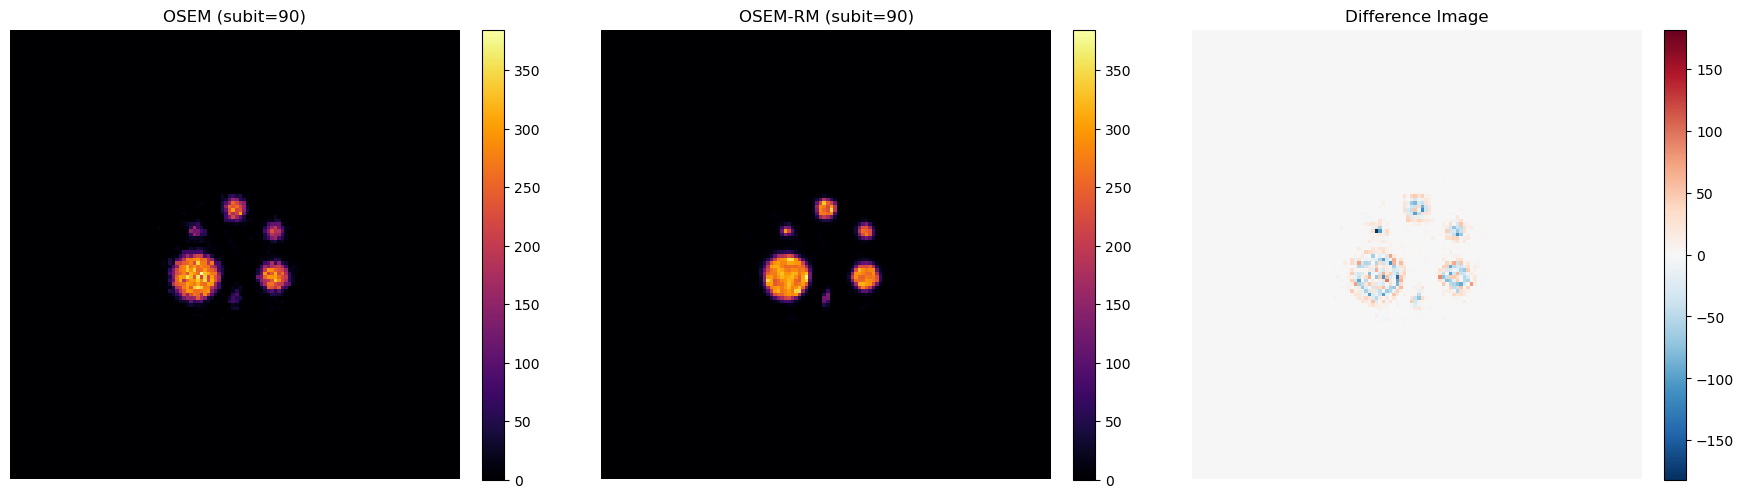

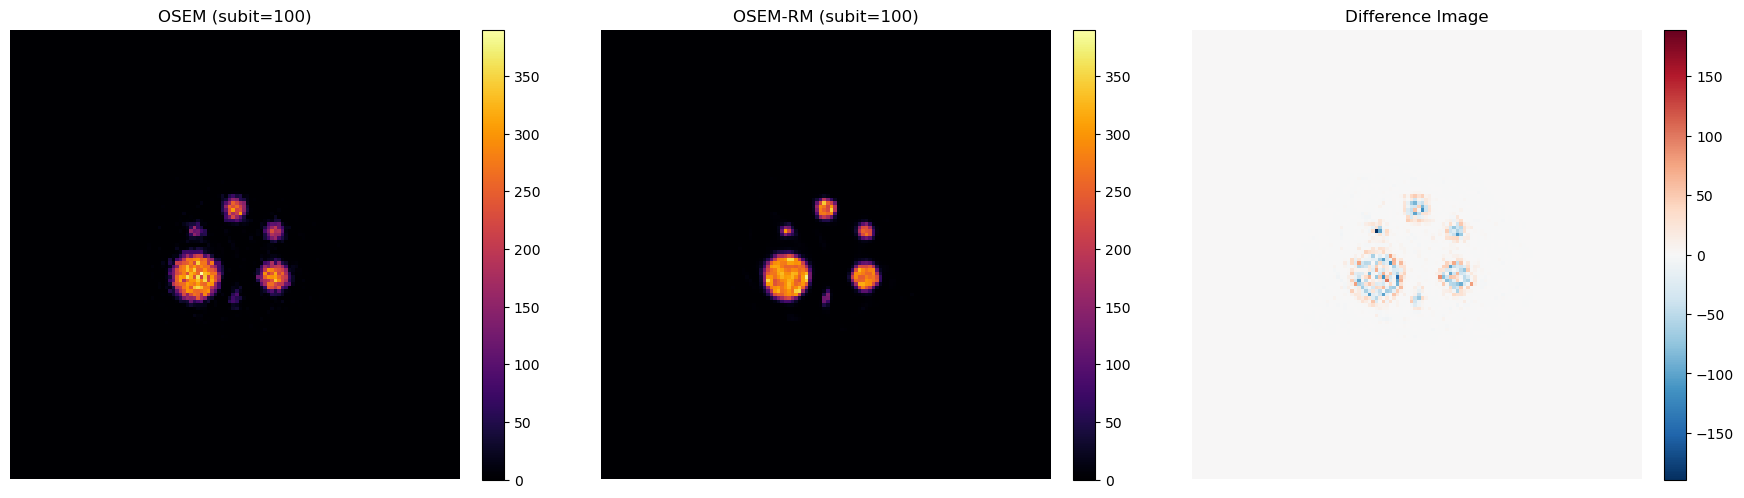

In [14]:
osem_recon_dir = Path("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_128/recons/osem")
osem_rm_recon_dir = Path("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/tc99m_128/recons/osem_rm")

idx= (56,slice(None),slice(None))

for it in range(10,101,10):
    osem_arr = spect.ImageData(str(osem_recon_dir / f"tc99m_sim_osem_{it}.hv")).as_array()
    osem_rm_arr = spect.ImageData(str(osem_rm_recon_dir / f"tc99m_sim_osem_rm_{it}.hv")).as_array()
    vmax=max(np.max(osem_arr[idx]), np.max(osem_rm_arr))

    utils.display_arr(
        arr_3d=[osem_arr, osem_rm_arr, osem_arr-osem_rm_arr],
        idx=idx,
        titles=[f"OSEM (subit={it})", f"OSEM-RM (subit={it})", "Difference Image"],
        vmax=[vmax, vmax, np.max(np.abs(osem_arr-osem_rm_arr))],
        cmap=["inferno", "inferno", "RdBu_r"]
    )